### **Harmonic Oscillator Simulation**

This Jupyter Notebook provides a Python simulation of a harmonic oscillator based on a MATLAB program from "Fingerübungen der Physik" by Michael Kaschke and Holger Cartarius. It explores different damping scenarios, forced oscillations, and the system's frequency response.

We'll use **NumPy** for all the mathematical calculations and **Matplotlib** for plotting the results.

First, let's import the necessary libraries.

In [1]:
# Import the libraries
import numpy as np
import matplotlib.pyplot as plt

# We'll define a simple color palette and line styles for consistent plotting.
# You can customize these arrays if you want to use different colors or styles.
def get_colors():
    """A simple color palette."""
    return plt.cm.viridis(np.linspace(0, 1, 6))

def get_line_styles():
    """A simple list of line styles."""
    return ['-', '-.', ':', '--', ':']

# Set global plotting parameters for better readability.
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.grid'] = True

---

### **1. Defining System Parameters**

Before we dive into the different scenarios, let's define the fundamental parameters of our oscillator.

* `m`: Mass of the oscillating object.
* `k`: The spring constant or restoring force constant.
* `q0`: Initial displacement.
* `qdot0`: Initial velocity.
* `omega0`: The **natural frequency** of the undamped oscillator, calculated as $\sqrt{k/m}$.

We'll also define the time range and the number of points for our simulation.

In [2]:
# --- Parameters ---
m = 0.2  # Mass [kg]
k = 1.0  # Restoring force constant [N/m]
q0 = 1.0  # Initial displacement [m]
qdot0 = 5.0  # Initial velocity [m/s]
omega0 = np.sqrt(k / m)  # Natural frequency [rad/s]

t_max = 8.0  # Maximum simulation time [s]
n_points = 500  # Number of data points
t = np.linspace(0, t_max, n_points)  # Time array

---

### **2. Damped and Undamped Oscillations (Part a)**

In this section, we'll simulate the oscillator under four different damping conditions:

1.  **Undamped**: No friction.
2.  **Weakly Damped**: The system oscillates with decreasing amplitude.
3.  **Overdamped**: The system returns to equilibrium without oscillating.
4.  **Critically Damped**: The system returns to equilibrium as quickly as possible without oscillating.

Each case corresponds to a specific solution to the differential equation of motion.

#### **Calculations**

We'll calculate the displacement `q(t)` for each damping scenario. The code includes checks to ensure the damping type matches the mathematical conditions (e.g., for weak damping, the discriminant must be positive).

In [3]:
# --- Part a) Calculations ---

# --- Undamped case ---
friction_term_undamped = 0.00  # Friction term
B_undamped = np.sqrt(q0**2 + qdot0**2 / omega0**2)  # Constant B
theta_undamped = np.arctan(omega0 * q0 / qdot0)  # Angle theta
q_undamped = B_undamped * np.sin(omega0 * t + theta_undamped)  # Undamped oscillator

# --- Weakly damped case ---
friction_term_weak = 0.05  # Friction term
gamma_weak = friction_term_weak / (2 * m)  # Damping parameter gamma
discriminant_weak = omega0**2 - gamma_weak**2  # Discriminant: must be positive for oscillations
if discriminant_weak <= 0:
    print('Warning: Damping is not weak for the given parameters.')
    q_weakly_damped = np.full_like(t, np.nan) # Use NaN to avoid plotting
    envelope = np.full_like(t, np.nan)
else:
    omega_weak = np.sqrt(discriminant_weak)  # Damped frequency
    B_weak = np.sqrt(q0**2 + (qdot0 + gamma_weak * q0)**2 / omega_weak**2)  # Constant B
    theta_weak = np.arctan(omega_weak * q0 / (qdot0 + gamma_weak * q0))  # Angle theta
    q_weakly_damped = B_weak * np.exp(-gamma_weak * t) * np.sin(omega_weak * t + theta_weak)
    envelope = B_weak * np.exp(-gamma_weak * t)  # Exponential envelope

# --- Overdamped case ---
friction_term_over = 1.2  # Friction term
fac_over = friction_term_over / (2 * m)
discriminant_over = fac_over**2 - k / m  # Discriminant: must be positive
if discriminant_over <= 0:
    print('Warning: Damping is not overdamped for the given parameters.')
    q_overdamped = np.full_like(t, np.nan)
else:
    gamma1_over = fac_over - np.sqrt(discriminant_over)
    gamma2_over = fac_over + np.sqrt(discriminant_over)
    A_over = q0 - (qdot0 + gamma1_over * q0) / (gamma1_over - gamma2_over)  # Constant A
    B_over = (qdot0 + gamma1_over * q0) / (gamma1_over - gamma2_over)  # Constant B
    q_overdamped = A_over * np.exp(-gamma1_over * t) + B_over * np.exp(-gamma2_over * t)

# --- Critically damped case ---
# The critical damping coefficient is eta_crit = 2 * m * omega0
friction_term_crit = 2 * m * omega0
gamma_crit = friction_term_crit / (2 * m)  # Damping parameter gamma
A_crit = q0  # Constant A
B_crit = qdot0 + gamma_crit * q0  # Constant B
q_critically_damped = (A_crit + B_crit * t) * np.exp(-gamma_crit * t)

#### **Visualization**

Now let's plot the displacement over time for all four damping scenarios to see how friction affects the motion.

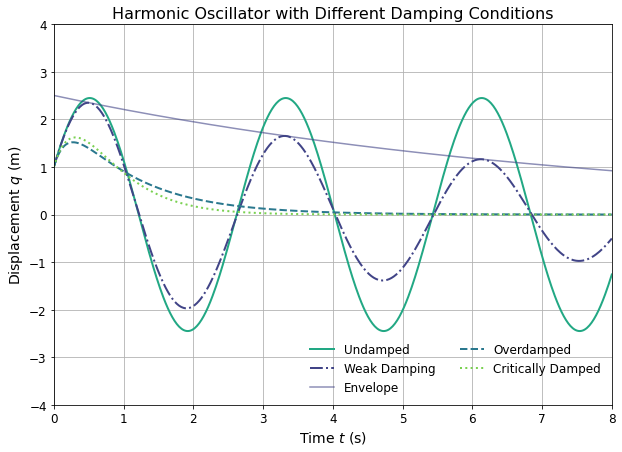

In [4]:
# --- Plotting Part a) ---
colors = get_colors()
styles = get_line_styles()

plt.figure(figsize=(10, 7))
plt.title('Harmonic Oscillator with Different Damping Conditions')
plt.plot(t, q_undamped, color=colors[3], linestyle=styles[0], label='Undamped')
if 'q_weakly_damped' in locals():
    plt.plot(t, q_weakly_damped, color=colors[1], linestyle=styles[1], label='Weak Damping')
    plt.plot(t, envelope, color=colors[1], linestyle=styles[0], linewidth=1.5, alpha=0.6, label='Envelope')
if 'q_overdamped' in locals():
    plt.plot(t, q_overdamped, color=colors[2], linestyle=styles[3], label='Overdamped')
if 'q_critically_damped' in locals():
    # Using a different color here for visibility in the plot
    plt.plot(t, q_critically_damped, color=colors[4], linestyle=styles[4], label='Critically Damped')

plt.ylabel('Displacement $q$ (m)')
plt.xlabel('Time $t$ (s)')
plt.legend(loc='lower right', ncol=2, frameon=False)
plt.xlim(0, t_max)
plt.ylim(-4, 4)
plt.show()

---

### **3. Forced Oscillations (Part b)**

Here, we introduce a sinusoidal driving force to the oscillator. We'll explore the oscillator's response by varying both the **driving frequency** and the **damping coefficient**.

#### **Calculations**

We'll define the driving force parameters and simulate the system's response over a longer time period. The total solution `q(t)` is the sum of the homogeneous solution (the transient decay) and the particular solution (the steady-state response).

In [5]:
# --- Part b) Calculations ---

# Driving force parameters
omega_driving_ratios = np.array([0.5, 0.9, 1.1, 1.5])  # Driving frequency ratios (omega_A / omega_0)
omega_driving_values = omega0 * omega_driving_ratios
eta_values = np.array([0.01, 0.05, 0.25, 0.75])  # Friction coefficients
f_amplitude = 0.5  # Driving amplitude [N]

# New time range for forced oscillations
t_max_forced = 50.0  # s
n_points_forced = 500
t_forced = np.linspace(0, t_max_forced, n_points_forced)  # Time array

# We need the initial conditions again for the homogeneous solution.
theta_hom = np.arctan(omega_weak * q0 / (qdot0 + gamma_weak * q0))
theta_init = theta_undamped # Use the initial theta from part a)
phi_excitation = 0 # Driving phase (set to zero)

# --- Subpart 1: Variable Driving Frequency (fixed damping) ---
q_freq_sweep = np.zeros((4, n_points_forced))
titles_freq_sweep = []
fixed_eta_index = 1  # We'll fix the damping to eta_values[1] = 0.05

for index, omega_a in enumerate(omega_driving_values):
    eta_fixed = eta_values[fixed_eta_index]
    gamma_fixed = eta_fixed / (2 * m)

    # Calculate the amplitude of the particular solution
    denominator_amp = np.sqrt((2 * gamma_fixed * omega_a)**2 + (omega0**2 - omega_a**2)**2)
    A_driving = f_amplitude / (m * denominator_amp)

    # Calculate the phase of the particular solution
    denominator_phase = (omega0**2 - omega_a**2)
    if np.isclose(denominator_phase, 0):
        denominator_phase = 1e-4  # Avoid division by zero at resonance

    if omega_a <= omega0:
        phi_phase = np.arctan(2 * gamma_fixed * omega_a / denominator_phase)
    else:
        # Phase shift by pi radians (180 degrees)
        phi_phase = np.pi + np.arctan(2 * gamma_fixed * omega_a / denominator_phase)

    # Phase of the total solution
    delta_phase = theta_init - phi_phase
    
    # Particular solution (steady-state)
    q_particular = A_driving * np.cos(omega_a * t_forced + delta_phase)
    
    # Homogeneous solution (transient decay)
    discriminant_hom = omega0**2 - gamma_fixed**2
    if discriminant_hom <= 0:
        print(f'Warning: Damping for gamma = {gamma_fixed:.3f} is too strong for the homogeneous solution.')
        q_homogeneous = np.full_like(t_forced, 0)
    else:
        omega_hom = np.sqrt(discriminant_hom)
        theta_hom = np.arctan(omega_hom * q0 / (qdot0 + gamma_fixed * q0))
        B_hom = np.sqrt(q0**2 + (qdot0 + gamma_fixed * q0)**2 / omega_hom**2)
        q_homogeneous = B_hom * np.exp(-gamma_fixed * t_forced) * np.sin(omega_hom * t_forced + theta_hom)
        
    q_freq_sweep[index, :] = q_particular + q_homogeneous
    titles_freq_sweep.append(f'$\gamma = {gamma_fixed:.3f}$, $\omega_A/\omega_0 = {omega_a/omega0:.3f}$')

#### **Visualization: Variable Frequency**

Let's see how the oscillator's motion changes as the driving frequency varies. Notice the large amplitude when the driving frequency is close to the natural frequency ($\omega_A / \omega_0 = 0.9$ and $1.1$).

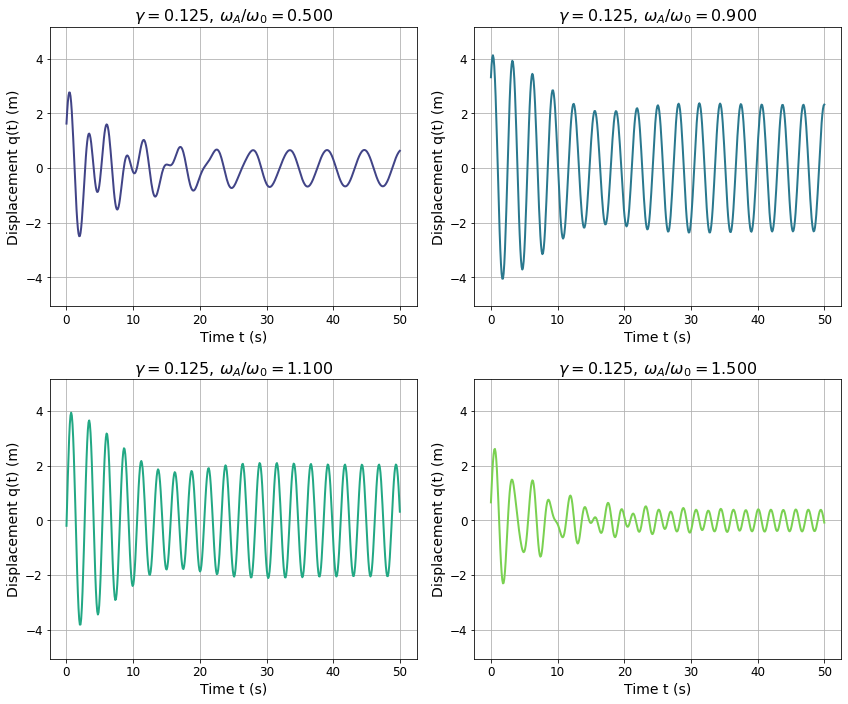

In [6]:
# --- Plotting Part b) - Variable Frequency ---
plt.figure(figsize=(12, 10))
for index in range(4):
    plt.subplot(2, 2, index + 1)
    plt.plot(t_forced, q_freq_sweep[index, :], color=colors[index + 1], linestyle=styles[0])
    plt.title(titles_freq_sweep[index])
    plt.ylabel('Displacement q(t) (m)')
    plt.xlabel('Time t (s)')
    
    # Set y-axis limits based on the second plot for consistency, as in the original code.
    y_min_limit = 1.25 * np.min(q_freq_sweep[1, :])
    y_max_limit = 1.25 * np.max(q_freq_sweep[1, :])
    plt.ylim(y_min_limit, y_max_limit)

plt.tight_layout()
plt.show()

#### **Calculations: Variable Damping**

Now, let's fix the driving frequency to a value close to the natural frequency ($\omega_A / \omega_0 = 0.9$) and vary the damping coefficient to see its effect on the response.

In [7]:
# --- Subpart 2: Variable Damping (fixed frequency) ---
q_damping_sweep = np.zeros((4, n_points_forced))
titles_damping_sweep = []
fixed_omega_index = 1  # We'll fix the driving frequency to omega_driving_values[1] = 0.9 * omega0

for index, eta in enumerate(eta_values):
    omega_a_fixed = omega_driving_values[fixed_omega_index]
    gamma_var = eta / (2 * m)
    
    # Calculate the amplitude of the particular solution
    denominator_amp_var = np.sqrt((2 * gamma_var * omega_a_fixed)**2 + (omega0**2 - omega_a_fixed**2)**2)
    A_driving_var = f_amplitude / (m * denominator_amp_var)

    # Calculate the phase of the particular solution
    denominator_phase_var = (omega0**2 - omega_a_fixed**2)
    if np.isclose(denominator_phase_var, 0):
        denominator_phase_var = 1e-4
        
    if omega_a_fixed <= omega0:
        phi_phase_var = np.arctan(2 * gamma_var * omega_a_fixed / denominator_phase_var)
    else:
        phi_phase_var = np.pi + np.arctan(2 * gamma_var * omega_a_fixed / denominator_phase_var)

    delta_phase_var = theta_init - phi_phase_var
    q_particular_var = A_driving_var * np.cos(omega_a_fixed * t_forced + delta_phase_var)
    
    # Homogeneous solution
    discriminant_hom_var = omega0**2 - gamma_var**2
    if discriminant_hom_var <= 0:
        q_homogeneous_var = np.full_like(t_forced, 0)
    else:
        omega_hom_var = np.sqrt(discriminant_hom_var)
        theta_hom_var = np.arctan(omega_hom_var * q0 / (qdot0 + gamma_var * q0))
        B_hom_var = np.sqrt(q0**2 + (qdot0 + gamma_var * q0)**2 / omega_hom_var**2)
        q_homogeneous_var = B_hom_var * np.exp(-gamma_var * t_forced) * np.sin(omega_hom_var * t_forced + theta_hom_var)
    
    q_damping_sweep[index, :] = q_particular_var + q_homogeneous_var
    titles_damping_sweep.append(f'$\gamma = {gamma_var:.3f}$, $\omega_A/\omega_0 = {omega_a_fixed/omega0:.3f}$')

#### **Visualization: Variable Damping**

A lower damping coefficient leads to a larger transient response and a larger steady-state amplitude.

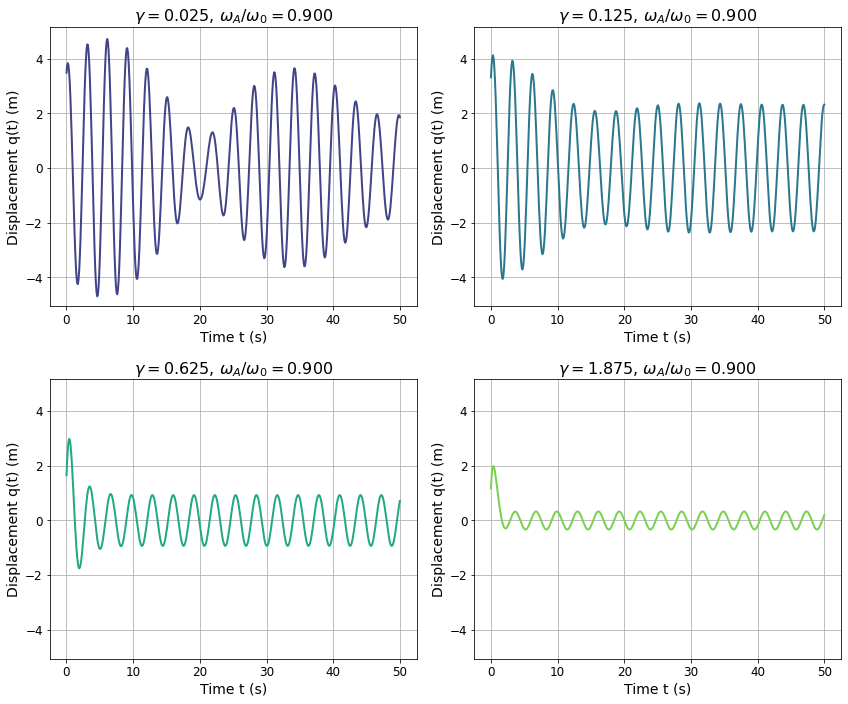

In [8]:
# --- Plotting Part b) - Variable Damping ---
plt.figure(figsize=(12, 10))
for index in range(4):
    plt.subplot(2, 2, index + 1)
    plt.plot(t_forced, q_damping_sweep[index, :], color=colors[index + 1], linestyle=styles[0])
    plt.title(titles_damping_sweep[index])
    plt.ylabel('Displacement q(t) (m)')
    plt.xlabel('Time t (s)')
    
    # Set y-axis limits based on the second plot's data for consistency.
    y_min_limit = 1.25 * np.min(q_damping_sweep[1, :])
    y_max_limit = 1.25 * np.max(q_damping_sweep[1, :])
    plt.ylim(y_min_limit, y_max_limit)
    
plt.tight_layout()
plt.show()

---

### **4. Frequency and Phase Response (Part c)**

In this final section, we'll analyze the system's **frequency response**. We'll plot the amplitude and phase of the steady-state response as a function of the driving frequency.

This is a classic demonstration of **resonance**.

#### **Calculations**

We'll sweep through a wide range of driving frequencies and calculate the corresponding amplitude and phase for different damping values.

IndexError: index 6 is out of bounds for axis 0 with size 6

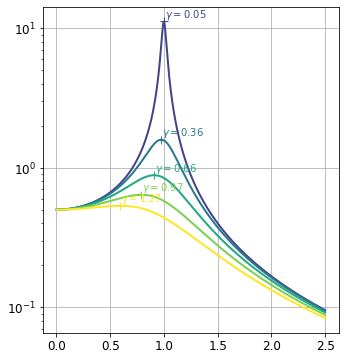

In [16]:
# --- Part c) Calculations ---

omega_min_c = 0.001 * omega0
omega_max_c = 2.5 * omega0
n_points_c = 500
omega_a_c = np.linspace(omega_min_c, omega_max_c, n_points_c)

# Define a range of damping coefficients (eta values).
eta_min_c = 0.02
eta_max_c = 2 * m * omega0 / np.sqrt(2)
eta_step_c = (eta_max_c - eta_min_c) / 5
eta_range = np.arange(eta_min_c, eta_max_c + eta_step_c / 2, eta_step_c)

# --- Plot 1: Amplitude vs. Frequency ---
plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
j_plot = 0
for eta in eta_range:
    gamma = eta / (2 * m)
    j_plot += 1
    
    # Vectorized calculation of amplitude
    discriminant_c_plot = (2 * gamma * omega_a_c)**2 + (omega0**2 - omega_a_c**2)**2
    amplitude = f_amplitude / (m * np.sqrt(discriminant_c_plot))
    
    plt.semilogy(omega_a_c / omega0, amplitude, color=colors[j_plot], linestyle=styles[0])
    
    # Calculate and plot the resonance peak for each damping curve
    if omega0**2 - 2 * gamma**2 > 0:
        omega_res = np.sqrt(omega0**2 - 2 * gamma**2)
        A_max = f_amplitude / (2 * m * gamma * np.sqrt(omega0**2 - gamma**2))
        
        plt.plot(omega_res / omega0, A_max, marker='+', markersize=8,
                 linewidth=1, color=colors[j_plot], linestyle='')
        plt.text(omega_res / omega0 + 0.01, A_max, f'$\gamma={gamma:.2f}$',
                 fontsize=10, color=colors[j_plot], verticalalignment='bottom')

plt.title('Amplitude vs. Excitation Frequency')
plt.ylabel('Amplitude $A$')
plt.xlabel('$\omega_A/\omega_0$')
plt.axis([0, 2.5, 0.1, 20])
plt.show()

#### **Visualization: Phase Difference**

The phase difference between the driving force and the oscillator's displacement changes from 0 to 180 degrees. At resonance ($\omega_A / \omega_0 = 1$), the phase shift is exactly 90 degrees.

IndexError: index 6 is out of bounds for axis 0 with size 6

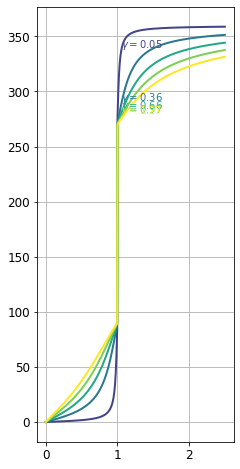

In [17]:
# --- Plot 2: Phase Difference ---
plt.subplot(1, 3, 2)
j_plot = 0
for eta in eta_range:
    gamma = eta / (2 * m)
    j_plot += 1
    
    # Vectorized phase calculation using arctan2 for quadrant handling
    phi_phase_deg = np.degrees(np.arctan2(2 * gamma * omega_a_c, (omega0**2 - omega_a_c**2)))
    
    # Add 180 degrees for the phase shift where omega_A > omega_0
    phi_phase_deg[omega_a_c > omega0] += 180
    
    plt.plot(omega_a_c / omega0, phi_phase_deg, color=colors[j_plot], linestyle=styles[0])
    
    # Add text label for each line
    idx_text = np.argmin(np.abs(omega_a_c/omega0 - 1.05))
    y_text = phi_phase_deg[idx_text] + 5
    plt.text(1.05, y_text, f'$\gamma={gamma:.2f}$', fontsize=10, color=colors[j_plot])

plt.title('Phase Difference')
plt.ylabel('Phase $\phi$ (degrees)')
plt.xlabel('$\omega_A/\omega_0$')
plt.axis([0, 2.5, 0, 180])
plt.show()

#### **Visualization: Power Transfer**

Finally, we'll plot the average power transferred from the driving force to the oscillator. The power transfer is maximal at the resonance frequency.

IndexError: index 6 is out of bounds for axis 0 with size 6

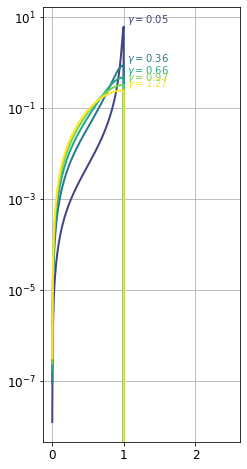

In [18]:
# --- Plot 3: Power Transfer ---
plt.subplot(1, 3, 3)
j_plot = 0
for eta in eta_range:
    gamma = eta / (2 * m)
    j_plot += 1
    
    # Recalculate amplitude and phase in radians for the power calculation.
    discriminant_power = (2 * gamma * omega_a_c)**2 + (omega0**2 - omega_a_c**2)**2
    amplitude_power = f_amplitude / (m * np.sqrt(discriminant_power))
    phi_power_rad = np.arctan2(2 * gamma * omega_a_c, (omega0**2 - omega_a_c**2))
    phi_power_rad[omega_a_c > omega0] += np.pi
    
    # Power is calculated as P = 0.5 * F_A * A * omega_A * sin(phi)
    power = 0.5 * f_amplitude * amplitude_power * omega_a_c * np.sin(phi_power_rad)
    
    plt.semilogy(omega_a_c / omega0, power, color=colors[j_plot], linestyle=styles[0])
    
    # Find the maximum power point and add a text label.
    max_power_val = np.max(power)
    idx_max_power = np.argmax(power)
    omega_max_power_ratio = omega_a_c[idx_max_power] / omega0
    
    plt.text(omega_max_power_ratio + 0.05, max_power_val, f'$\gamma={gamma:.2f}$',
             fontsize=10, color=colors[j_plot], verticalalignment='bottom')
    
plt.title('Power Transfer')
plt.ylabel('Power $P$')
plt.xlabel('$\omega_A/\omega_0$')
plt.axis([0, 2.5, 0.01, 10])
plt.tight_layout()
plt.show()